Start training...
Epoch   0 | Loss: 0.5886 ± 0.6201
Epoch   8 | Loss: -0.0020 ± 0.0521
Training completed!


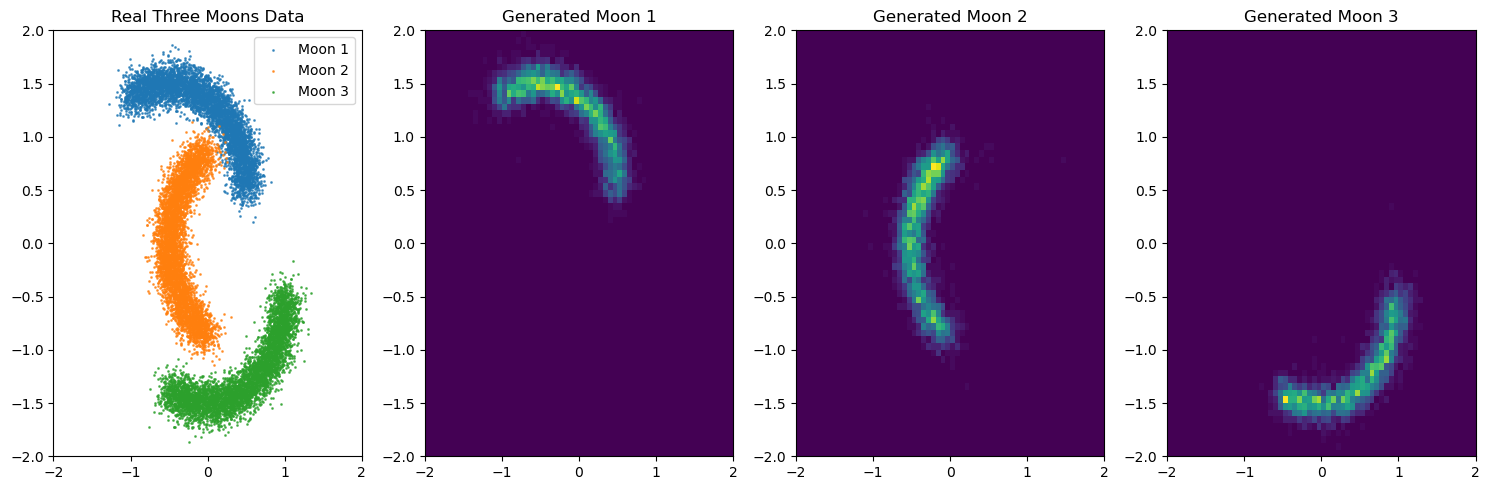

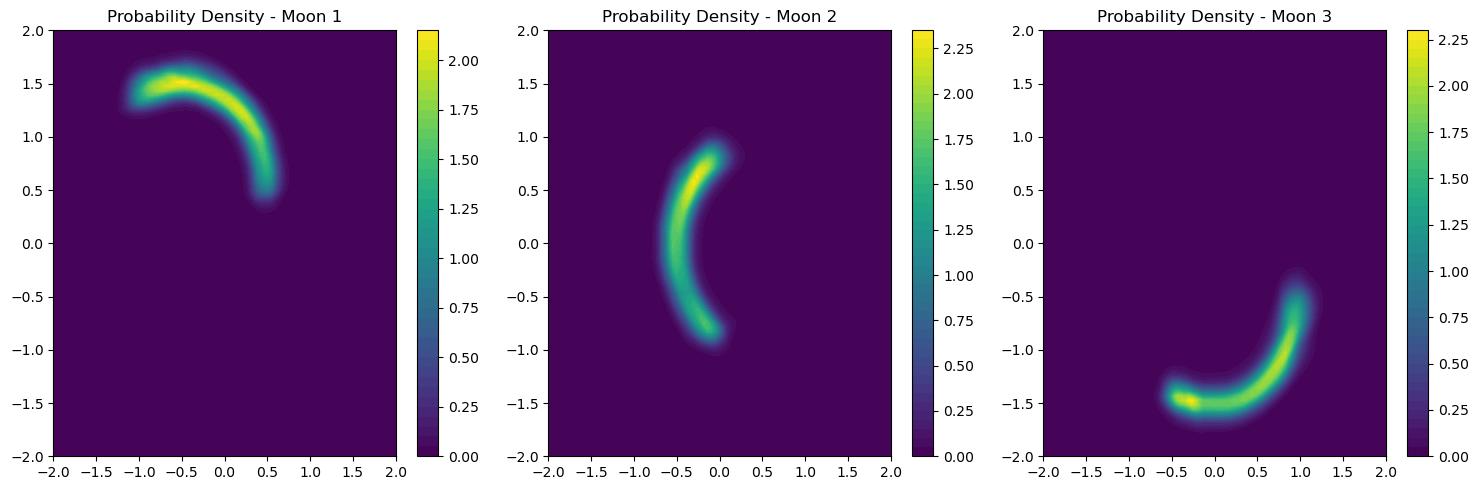

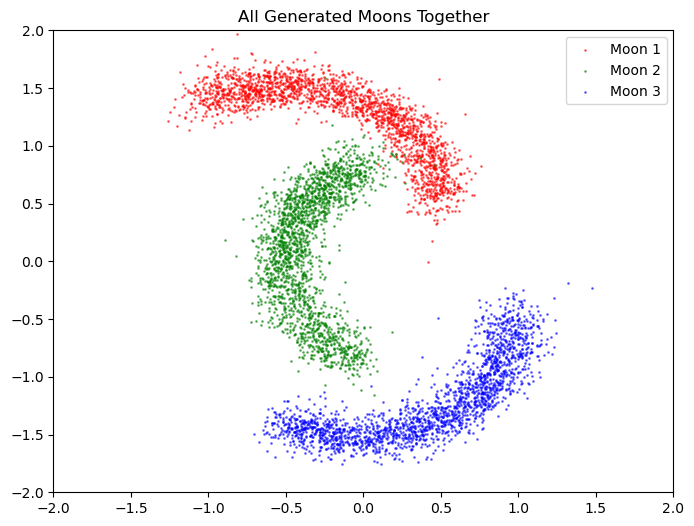


Final Evaluation:
Moon 1 Test Log-Likelihood: 0.0532
Moon 2 Test Log-Likelihood: 0.0379
Moon 3 Test Log-Likelihood: 0.0022
Overall Test Log-Likelihood: 0.0314


In [1]:
import torch
import zuko
from torch import distributions, optim, nn, utils
from matplotlib import pyplot as plt
import numpy as np

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# تولید داده‌های سه ماه (Three Moons)
def three_moons(n: int, sigma: float = 1e-1):
    theta = 2 * torch.pi * torch.rand(n)
    label = torch.zeros(n, dtype=torch.long)
    
    # تقسیم دایره به سه بخش
    mask1 = (theta < 2*torch.pi/3)
    mask2 = (theta >= 2*torch.pi/3) & (theta < 4*torch.pi/3)
    mask3 = (theta >= 4*torch.pi/3)
    
    label[mask1] = 0
    label[mask2] = 1
    label[mask3] = 2
    
    x = torch.zeros(n, 2)
    
    # ماه اول
    x[mask1, 0] = torch.cos(theta[mask1]) - 0.5
    x[mask1, 1] = torch.sin(theta[mask1]) + 0.5
    
    # ماه دوم
    x[mask2, 0] = torch.cos(theta[mask2]) + 0.5
    x[mask2, 1] = torch.sin(theta[mask2])
    
    # ماه سوم
    x[mask3, 0] = torch.cos(theta[mask3])
    x[mask3, 1] = torch.sin(theta[mask3]) - 0.5
    
    # اضافه کردن نویز
    x = torch.normal(x, sigma)
    
    return x, label

# تولید داده‌های آموزشی
samples, labels = three_moons(16384)

# نمایش داده‌های اصلی
plt.figure(figsize=(15, 5))

# داده‌های واقعی
plt.subplot(1, 4, 1)
for i in range(3):
    mask = (labels == i)
    plt.scatter(samples[mask, 0], samples[mask, 1], s=1, label=f'Moon {i+1}', alpha=0.7)
plt.title('Real Three Moons Data')
plt.legend()
plt.xlim(-2, 2)
plt.ylim(-2, 2)

# ایجاد DataLoader
dataset = utils.data.TensorDataset(samples, labels)
trainloader = utils.data.DataLoader(dataset, batch_size=256, shuffle=True)

# ایجاد مدل جریان شرطی برای سه کلاس
flow = zuko.flows.NSF(
    features=2,      # بعد داده‌ها (x, y)
    context=1,       # بعد شرط (برچسب کلاس)
    transforms=5,    # تعداد لایه‌های تبدیل
    hidden_features=(128, 128),  # شبکه عصبی داخلی
)

# بهینه‌ساز
optimizer = optim.Adam(flow.parameters(), lr=1e-3)

# آموزش مدل
print("Start training...")
for epoch in range(16):
    losses = []
    
    for x, label in trainloader:
        # تبدیل برچسب به شکل مناسب (batch_size, 1)
        c = label.float().unsqueeze(-1)
        
        # محاسبه loss
        loss = -flow(c).log_prob(x).mean()
        
        # پس‌انتشار
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        losses.append(loss.detach())
    
    # میانگین loss در این epoch
    losses = torch.stack(losses)
    if epoch % 8 == 0:
        print(f'Epoch {epoch:3d} | Loss: {losses.mean():.4f} ± {losses.std():.4f}')

print("Training completed!")

# نمونه‌گیری و نمایش نتایج برای هر کلاس
plt.subplot(1, 4, 2)
samples_moon1 = flow(torch.tensor([0.0])).sample((4096,))
plt.hist2d(samples_moon1[:, 0], samples_moon1[:, 1], bins=64, range=[[-2, 2], [-2, 2]], cmap='viridis')
plt.title('Generated Moon 1')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.subplot(1, 4, 3)
samples_moon2 = flow(torch.tensor([1.0])).sample((4096,))
plt.hist2d(samples_moon2[:, 0], samples_moon2[:, 1], bins=64, range=[[-2, 2], [-2, 2]], cmap='viridis')
plt.title('Generated Moon 2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.subplot(1, 4, 4)
samples_moon3 = flow(torch.tensor([2.0])).sample((4096,))
plt.hist2d(samples_moon3[:, 0], samples_moon3[:, 1], bins=64, range=[[-2, 2], [-2, 2]], cmap='viridis')
plt.title('Generated Moon 3')
plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

# نمایش چگالی احتمال برای هر کلاس با contour plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ایجاد grid برای محاسبه چگالی احتمال
x_grid = np.linspace(-2, 2, 100)
y_grid = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_grid, y_grid)
grid_points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32)

for i, ax in enumerate(axes):
    # محاسبه log probability برای grid
    with torch.no_grad():
        c_condition = torch.full((grid_points.shape[0], 1), float(i))
        log_probs = flow(c_condition).log_prob(grid_points)
        probs = torch.exp(log_probs).numpy().reshape(100, 100)
    
    # رسم contour plot
    contour = ax.contourf(X, Y, probs, levels=50, cmap='viridis')
    ax.set_title(f'Probability Density - Moon {i+1}')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    fig.colorbar(contour, ax=ax)

plt.tight_layout()
plt.show()

# نمونه‌گیری همزمان از همه کلاس‌ها
plt.figure(figsize=(8, 6))
all_samples = []
colors = ['red', 'green', 'blue']

for i in range(3):
    samples = flow(torch.tensor([float(i)])).sample((2048,))
    all_samples.append(samples)
    plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5, label=f'Moon {i+1}', c=colors[i])

plt.title('All Generated Moons Together')
plt.legend()
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

# ارزیابی نهایی
print("\nFinal Evaluation:")
with torch.no_grad():
    test_samples, test_labels = three_moons(2048)
    
    total_log_prob = 0
    for i in range(3):
        mask = (test_labels == i)
        if mask.sum() > 0:
            c_test = torch.full((mask.sum(), 1), float(i))
            log_prob = flow(c_test).log_prob(test_samples[mask])
            total_log_prob += log_prob.sum()
            print(f'Moon {i+1} Test Log-Likelihood: {log_prob.mean():.4f}')
    
    print(f'Overall Test Log-Likelihood: {total_log_prob / len(test_samples):.4f}')

In [12]:
for x, label in trainloader:
    c = label.float().unsqueeze(-1)
    print(x[0],label[0], c[0])
    print(x.shape,label.shape, c.shape)
    break

tensor([-0.0207, -1.4527]) tensor(2) tensor([2.])
torch.Size([256, 2]) torch.Size([256]) torch.Size([256, 1])
